# k-nearest neighbours

Combines the second half of the KNN imputer colab (the imputer part moved to the preprocessing notebook)
the KNN regressor on California housing colab and the KNN on MNIST colab, filled out with experiments on
`k`, scaling and weighting.

## Idea

To predict for a new point, find the `k` training points closest to it and

* **classification**: take a majority vote of their labels
* **regression**: average their values

Things to know about it:

* **non-parametric** - it doesn't learn weights or any fixed set of parameters
* **lazy** - `fit` just stores the training data, all the work happens at prediction time
* prediction is expensive: distance to every training point for every query
* the whole training set has to be kept in memory
* it's supervised, so it needs labels (not the same thing as k-means clustering)
* distances are scale dependent, so **scale the features** first

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier, KNeighborsRegressor

## NearestNeighbors

The building block that `KNeighborsClassifier` uses internally. It only finds neighbours, no prediction.

Distances from `[0, 0, 1.3]` to each of three points:

In [2]:
X = [[0, 0, 2],
     [1, 0, 0],
     [0, 0, 1]]

nn = NearestNeighbors(n_neighbors=3, metric="euclidean").fit(X)
distances, indices = nn.kneighbors([[0, 0, 1.3]])
print("distances:", distances.round(3))
print("indices:  ", indices)

distances: [[0.3  0.7  1.64]]
indices:   [[2 0 1]]


Closest is index 2 (`[0, 0, 1]`, distance 0.3), then index 0 (0.7), then index 1
($\sqrt{1 + 1.3^2} \approx 1.64$).

## A small classification example

In [3]:
X_train = np.array([[1, 100], [4, 400], [5, 500], [6, 600], [8, 800], [9, 900],
                    [11, 1100], [12, 1200], [15, 1500], [18, 1800], [19, 1900]])
y_train = np.array([0, 0, 1, 1, 1, 2, 2, 2, 2, 2, 2])

knn = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
knn.predict([[2, 200]])

array([0])

In [4]:
dist, idx = knn.kneighbors([[2, 200]])
print("neighbours:", X_train[idx[0]].tolist())
print("labels:    ", y_train[idx[0]])
print("distances: ", dist.round(1))

neighbours: [[1, 100], [4, 400], [5, 500]]
labels:     [0 0 1]
distances:  [[100. 200. 300.]]


Two of the three neighbours are class 0, so the prediction is 0.

Now with `k` = the whole training set:

In [5]:
KNeighborsClassifier(n_neighbors=len(y_train)).fit(X_train, y_train).predict([[2, 200]])

array([2])

Every point votes, so the answer is just the most common class overall (class 2, six out of eleven),
no matter where the query is. That's the extreme case of underfitting.

Also note the distances above: they're basically just the second feature, since it's 100 times bigger.
The first feature contributes almost nothing. That's the scaling problem, more on it below.

## Effect of k on the decision boundary

* small `k` follows individual points closely: jagged boundary, overfitting
* large `k` averages over many points: smooth boundary, eventually underfitting

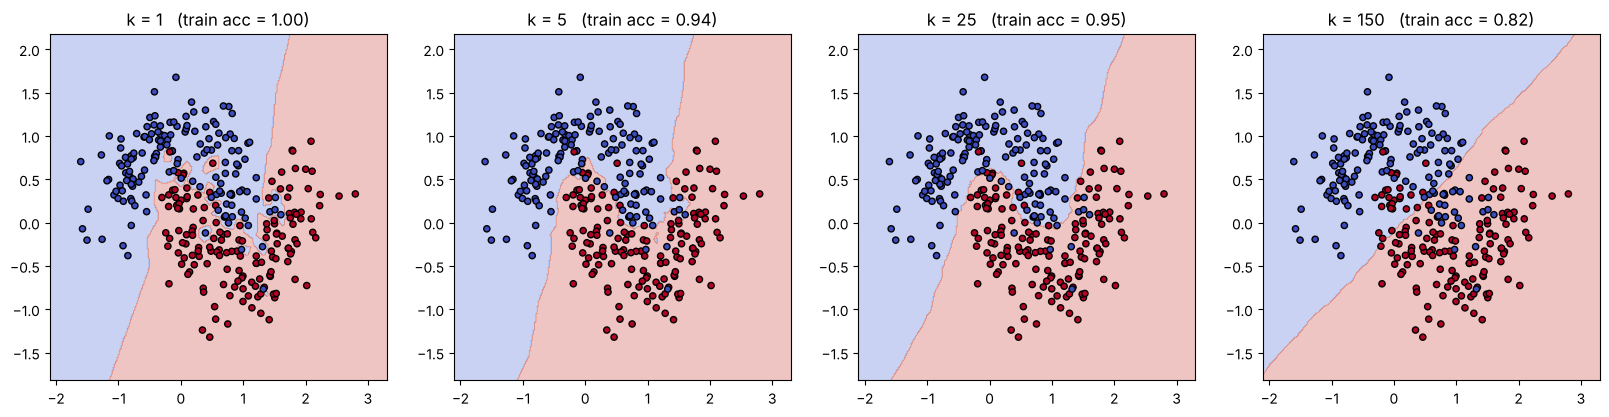

In [6]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.3, random_state=0)
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
                     np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, k in zip(axes, [1, 5, 25, 150]):
    model = KNeighborsClassifier(n_neighbors=k).fit(X, y)
    zz = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=20)
    ax.set_title(f"k = {k}   (train acc = {model.score(X, y):.2f})")
plt.show()

`k = 1` gets 100% on the training data because every point is its own nearest neighbour. That number
means nothing. `k = 150` (half the dataset) has lost most of the moon shape.

## Picking k with cross validation

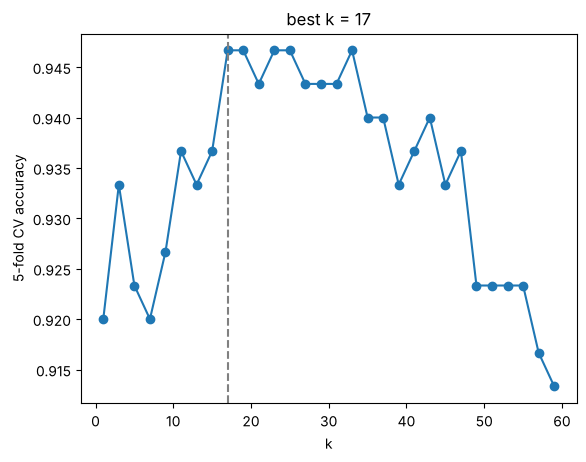

In [7]:
from sklearn.model_selection import cross_val_score

ks = range(1, 61, 2)
cv_acc = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X, y, cv=5).mean() for k in ks]

best_k = list(ks)[int(np.argmax(cv_acc))]
plt.plot(list(ks), cv_acc, marker="o")
plt.axvline(best_k, ls="--", c="grey")
plt.xlabel("k"); plt.ylabel("5-fold CV accuracy")
plt.title(f"best k = {best_k}")
plt.show()

Odd values of `k` avoid ties in binary classification.

## Scaling matters

The wine dataset has features on very different scales (proline is in the hundreds to thousands, hue
is around 1). Same model, with and without a `StandardScaler` in front:

In [8]:
from sklearn.datasets import load_wine
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_wine, y_wine = load_wine(return_X_y=True, as_frame=True)
X_wine[['proline', 'magnesium', 'hue', 'nonflavanoid_phenols']].describe().loc[['min', 'max']]

,proline,magnesium,hue,nonflavanoid_phenols
min,278.0,70.0,0.48,0.13
max,1680.0,162.0,1.71,0.66


In [9]:
raw = KNeighborsClassifier(n_neighbors=5)
scaled = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))

print(f"without scaling: {cross_val_score(raw, X_wine, y_wine, cv=5).mean():.3f}")
print(f"with scaling:    {cross_val_score(scaled, X_wine, y_wine, cv=5).mean():.3f}")

without scaling: 0.691
with scaling:    0.949


Without scaling, distance is almost entirely decided by `proline`, and the other 12 features are
basically ignored.

## Weights: uniform vs distance

`weights="uniform"` gives each of the `k` neighbours one vote. `weights="distance"` weights each vote by
1 / distance, so closer neighbours count more (and an exact match wins outright).

In [10]:
for w in ["uniform", "distance"]:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15, weights=w))
    print(f"{w:9s} {cross_val_score(pipe, X_wine, y_wine, cv=5).mean():.3f}")

uniform   0.955
distance  0.955


No difference on this data. Distance weighting tends to matter more with larger `k`, or when some
neighbours are much further away than others.

## Regression

`KNeighborsRegressor` averages the neighbours' target values, which gives a step-like prediction curve.

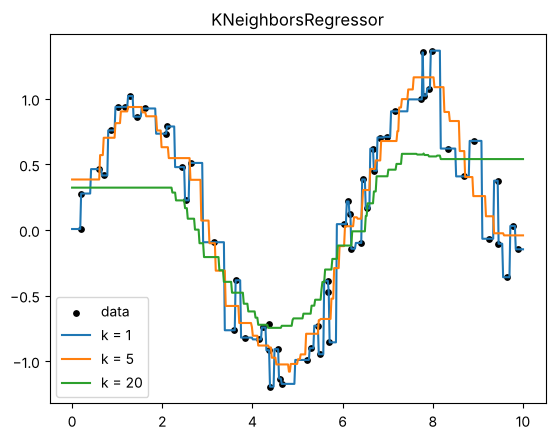

In [11]:
rng = np.random.RandomState(0)
X_r = np.sort(rng.rand(60, 1) * 10, axis=0)
y_r = np.sin(X_r).ravel() + rng.randn(60) * 0.2
x_plot = np.linspace(0, 10, 500).reshape(-1, 1)

plt.scatter(X_r, y_r, c="k", s=15, label="data")
for k in [1, 5, 20]:
    plt.plot(x_plot, KNeighborsRegressor(n_neighbors=k).fit(X_r, y_r).predict(x_plot), label=f"k = {k}")
plt.legend()
plt.title("KNeighborsRegressor")
plt.show()

Same trade-off as before: `k = 1` passes through every point (including the noise), `k = 20` is too
flat to follow the curve properly.

## KNN regression on California housing

A real-sized test. 70/30 split as in the course colab.

In [12]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

X_cal, y_cal = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X_cal, y_cal, test_size=0.30, random_state=8)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

(`mean_squared_error(..., squared=False)` from the original was removed in recent sklearn versions,
hence the small helper.)

Scaled vs unscaled with k = 2:

In [13]:
for name, model in [("no scaling", KNeighborsRegressor(n_neighbors=2)),
                    ("MinMaxScaler", Pipeline([("scaler", MinMaxScaler()), ("knn", KNeighborsRegressor(n_neighbors=2))]))]:
    model.fit(X_train, y_train)
    print(f"{name:13s} test RMSE: {rmse(y_test, model.predict(X_test)):.3f}")

no scaling    test RMSE: 1.120


MinMaxScaler  test RMSE: 0.677


Without scaling, Population (in the thousands) dominates the distance and the result is much worse.

### Choosing k

The course colab picked k by looping over values and checking the error on the **test set**. That makes
the test set part of model selection, so the final test score is optimistic. Cross validation on the
training set is the right way:

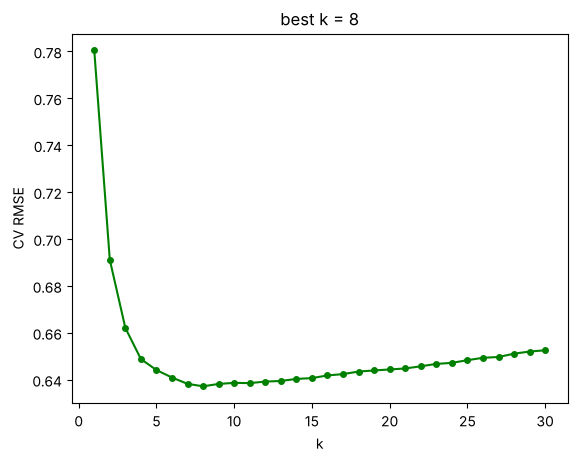

In [14]:
knn_pipe = Pipeline([("scaler", MinMaxScaler()), ("knn", KNeighborsRegressor())])
kf = KFold(n_splits=5, shuffle=True, random_state=0)

grid = GridSearchCV(knn_pipe, {"knn__n_neighbors": list(range(1, 31))},
                    cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)

cv_rmse = -grid.cv_results_["mean_test_score"]
plt.plot(range(1, 31), cv_rmse, "g-o", markersize=4)
plt.xlabel("k"); plt.ylabel("CV RMSE")
plt.title(f"best k = {grid.best_params_['knn__n_neighbors']}")
plt.show()

In [15]:
print(f"best k: {grid.best_params_['knn__n_neighbors']}")
print(f"CV RMSE:   {-grid.best_score_:.3f}")
print(f"test RMSE: {rmse(y_test, grid.predict(X_test)):.3f}")

best k: 8
CV RMSE:   0.637
test RMSE: 0.620


The curve is the usual shape: k = 1 is noisy (overfitting), the error drops quickly, then slowly creeps
back up as k grows and predictions get too smooth.

The course's grid search ran on the raw features (no scaler in the search), which is why it reported an
RMSE of about 1.06 there instead of about 0.6.

`RandomizedSearchCV` with the same list of k values tries a random subset instead of all 30. With one
parameter and cheap fits there's no real reason to use it here.

### Adding polynomial features

In [16]:
poly_knn = Pipeline([("poly", PolynomialFeatures(include_bias=False)),
                     ("scaler", MinMaxScaler()),
                     ("knn", KNeighborsRegressor())])
poly_grid = GridSearchCV(poly_knn, {"poly__degree": [1, 2], "knn__n_neighbors": [5, 7, 9, 11]},
                         cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1)
poly_grid.fit(X_train, y_train)

print("best:", poly_grid.best_params_, f" CV RMSE: {-poly_grid.best_score_:.3f}")
pd.DataFrame(poly_grid.cv_results_).pivot_table(index="param_poly__degree", columns="param_knn__n_neighbors",
                                               values="mean_test_score").mul(-1).round(3)

best: {'knn__n_neighbors': 9, 'poly__degree': 1}  CV RMSE: 0.638


param_knn__n_neighbors,5,7,9,11
param_poly__degree,,,,
1,0.644,0.638,0.638,0.639
2,0.674,0.665,0.662,0.663


Degree 1 wins, same as in the course colab. Polynomial features help a linear model by letting it bend,
but KNN is already non-linear. For KNN they mainly add extra dimensions to the distance calculation, and
the squared and product columns end up dominating it.

## KNN classification on MNIST

From the KNN MNIST colab. Same data as the perceptron and logistic regression notebooks.

In [17]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, precision_score
from sklearn.pipeline import make_pipeline

Xm, ym = fetch_openml('mnist_784', version=1, return_X_y=True)
Xm, ym = Xm.to_numpy(), ym.to_numpy()
xm_train, xm_test, ym_train, ym_test = Xm[:60000], Xm[60000:], ym[:60000], ym[60000:]

ym_train_0 = np.where(ym_train == '0', 1, -1)
ym_test_0 = np.where(ym_test == '0', 1, -1)

### Looking at the data in 2D

PCA down to 2 components to get a rough picture of where the zeros sit relative to everything else.

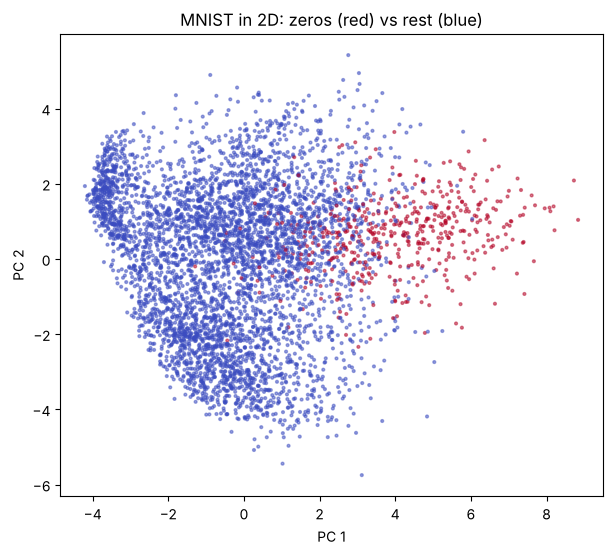

In [18]:
pipe_pca_2d = make_pipeline(MinMaxScaler(), PCA(n_components=2))
x_train_2d = pipe_pca_2d.fit_transform(xm_train)

plt.figure(figsize=(7, 6))
idx = np.random.RandomState(0).choice(len(x_train_2d), 5000, replace=False)
plt.scatter(x_train_2d[idx, 0], x_train_2d[idx, 1], c=ym_train_0[idx], cmap='coolwarm', s=4, alpha=0.5)
plt.xlabel('PC 1'); plt.ylabel('PC 2'); plt.title('MNIST in 2D: zeros (red) vs rest (blue)')
plt.show()

The zeros mostly cluster on one side, but overlap with the other digits. Two dimensions out of 784 lose a
lot of information.

### KNN by hand on 10 points

Five zeros and five other digits from the training set, and the first 10 test images, all in the 2D PCA
space. k = 3.

In [19]:
pos = np.where(ym_train_0 == 1)[0][:5]
neg = np.where(ym_train_0 == -1)[0][:5]
x10 = np.vstack([xm_train[pos], xm_train[neg]])
y10 = np.hstack([ym_train_0[pos], ym_train_0[neg]])

knn_2d = make_pipeline(pipe_pca_2d, KNeighborsClassifier(n_neighbors=3)).fit(x10, y10)
y_hat10 = knn_2d.predict(xm_test[:10])
print("test labels:", ym_test_0[:10])
print("predicted:  ", y_hat10)

test labels: [-1 -1 -1  1 -1 -1 -1 -1 -1 -1]
predicted:   [-1 -1 -1  1 -1 -1 -1 -1 -1 -1]


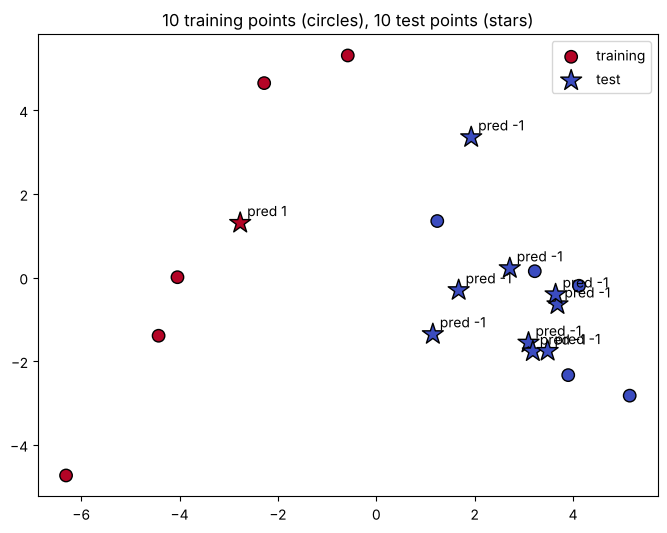

In [20]:
train_2d = pipe_pca_2d.transform(x10)
test_2d = pipe_pca_2d.transform(xm_test[:10])

plt.figure(figsize=(8, 6))
plt.scatter(train_2d[:, 0], train_2d[:, 1], c=y10, cmap='coolwarm', s=80, edgecolor='k', label='training')
plt.scatter(test_2d[:, 0], test_2d[:, 1], c=ym_test_0[:10], cmap='coolwarm', marker='*', s=250, edgecolor='k', label='test')
for i, (px, py) in enumerate(test_2d):
    plt.annotate(f"pred {y_hat10[i]}", (px, py), textcoords='offset points', xytext=(5, 5))
plt.legend(); plt.title('10 training points (circles), 10 test points (stars)')
plt.show()

In [21]:
nn = NearestNeighbors(n_neighbors=3).fit(train_2d)
dist, idx = nn.kneighbors(test_2d[:3])
for i in range(3):
    print(f"test {i}: neighbours {idx[i]}, labels {y10[idx[i]]}, distances {dist[i].round(2)} -> predict {y_hat10[i]}")

test 0: neighbours [9 7 5], labels [-1 -1 -1], distances [0.51 1.47 1.86] -> predict -1
test 1: neighbours [5 2 9], labels [-1  1 -1], distances [2.12 3.18 3.45] -> predict -1
test 2: neighbours [7 9 8], labels [-1 -1 -1], distances [0.62 0.92 1.71] -> predict -1


Each prediction is just the majority label among the three nearest training points. Here all ten
predictions happen to be right, including the one real zero (test 3), but with ten training points that's
mostly luck: the course's run of the same idea gave several false positives.

### More data, still 2D

10,000 training images:

In [22]:
knn_2d.fit(xm_train[:10000], ym_train_0[:10000])
print(classification_report(ym_test_0, knn_2d.predict(xm_test)))

              precision    recall  f1-score   support

          -1       0.96      0.96      0.96      9020
           1       0.65      0.63      0.64       980

    accuracy                           0.93     10000
   macro avg       0.81      0.80      0.80     10000
weighted avg       0.93      0.93      0.93     10000



The course then looped over k = 1..19 with `pipe_clf_pca_2d.__n_neighbors = k`. That line doesn't change the
model, it just adds an unused attribute to the pipeline object, so every iteration trained the same k=3 model
and the plot was flat. `set_params` is the way to change a parameter inside a pipeline:

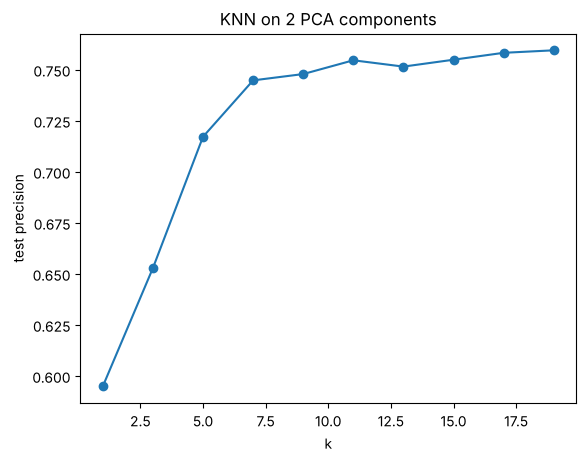

In [23]:
ks = range(1, 20, 2)
precisions = []
for k in ks:
    knn_2d.set_params(kneighborsclassifier__n_neighbors=k).fit(xm_train[:10000], ym_train_0[:10000])
    precisions.append(precision_score(ym_test_0, knn_2d.predict(xm_test)))

plt.plot(list(ks), precisions, 'o-')
plt.xlabel('k'); plt.ylabel('test precision'); plt.title('KNN on 2 PCA components')
plt.show()

Precision rises with k: averaging over more neighbours makes the classifier more cautious about calling
something a zero in the overlapping region. (Choosing k on the test set like this is fine for a picture,
not for picking the final model.)

### All 784 features

Distances on the full images. The course grid search over k on all 60,000 images took about 20 minutes,
so this searches on 10,000 with 3 folds.

In [24]:
pipe_knn = make_pipeline(MinMaxScaler(), KNeighborsClassifier())
search = GridSearchCV(pipe_knn, {'kneighborsclassifier__n_neighbors': [1, 3, 5, 7, 9, 11]},
                      scoring='f1', cv=3, n_jobs=-1)
search.fit(xm_train[:10000], ym_train_0[:10000])
pd.Series(search.cv_results_['mean_test_score'], index=[1, 3, 5, 7, 9, 11], name='CV F1').round(4)

1     0.9758
3     0.9783
5     0.9778
7     0.9801
9     0.9787
11    0.9782
Name: CV F1, dtype: float64

All values of k are within half a percent of each other. k = 7 comes out best, the same as the course found
scoring on precision.

Training error with k = 7 vs k = 1:

In [25]:
for k in [7, 1]:
    m = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=k)).fit(xm_train[:10000], ym_train_0[:10000])
    print(f"k={k}: training accuracy {m.score(xm_train[:10000], ym_train_0[:10000]):.4f}")

k=7: training accuracy 0.9980


k=1: training accuracy 1.0000


k = 1 gives 100% training accuracy (each point's nearest neighbour is itself, as long as there are no exact
duplicates with different labels). With k = 7 some training points are outvoted by their neighbours, so
training accuracy isn't 100%, which surprised the course notes.

### Multiclass

KNN handles any number of classes directly, no one-vs-rest needed: just a majority vote among the
neighbours' digit labels. On the full 60,000 / 10,000 split:

In [26]:
%%time
pipe_knn = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=3, n_jobs=-1))
pipe_knn.fit(xm_train, ym_train)
y_hat = pipe_knn.predict(xm_test)
print(classification_report(ym_test, y_hat))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.96      1.00      0.98      1135
           2       0.98      0.97      0.97      1032
           3       0.96      0.97      0.96      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.96      0.96       892
           6       0.98      0.99      0.98       958
           7       0.96      0.96      0.96      1028
           8       0.99      0.94      0.96       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

CPU times: user 17.9 s, sys: 1.94 s, total: 19.8 s
Wall time: 11.3 s


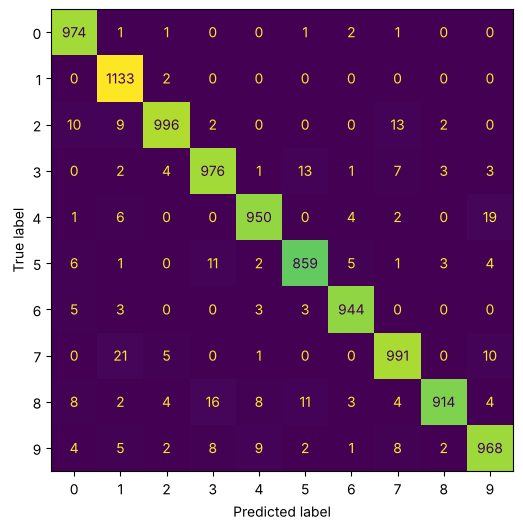

In [27]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(ym_test, y_hat, ax=ax, colorbar=False)
plt.show()

About 97%, better than every linear model on MNIST, with no training at all. The cost is at prediction
time: every test image is compared with all 60,000 training images (see the wall time above).

## Summary

| | |
|---|---|
| main hyperparameter | `n_neighbors` (k) |
| other options | `weights` ('uniform' / 'distance'), `metric` (default Minkowski with p=2, i.e. Euclidean) |
| small k | low bias, high variance (overfits) |
| large k | high bias, low variance (underfits) |
| always | scale features first |
| downside | slow predictions and memory use on large datasets |

## References

* [sklearn nearest neighbours guide](https://scikit-learn.org/stable/modules/neighbors.html)